## First Implementation of the TFT with only Macro Variables

### Inspecting & Importing Data

In [15]:
import pytorch_forecasting
import warnings
from tqdm import tqdm
warnings.filterwarnings("ignore")
import pandas as pd
import os
import matplotlib.pyplot as plt
import holidays
# different than original example
import lightning.pytorch as pl
import torch
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

In [16]:
# os.getcwd()
monthly_path = '/Users/minna/Code/FS26/AML/aml2026-group-3/data/macro-vars-monthly.csv'
df_monthly = pd.read_csv(monthly_path)
df_monthly = df_monthly.rename(columns = {'Unnamed: 0':'date'})
df_monthly['date'] = pd.to_datetime(df_monthly['date'])
print(df_monthly.tail(10))

           date      CPI    PCEPI    PAYEMS  JTSJOL  UMCSENT    INDPRO  UNRATE
1277 2025-06-01  321.435  126.743  158478.0  7204.0     60.7  101.4785     4.1
1278 2025-07-01  322.169  126.960  158542.0  7089.0     61.7  101.8940     4.3
1279 2025-08-01  323.291  127.293  158472.0  6919.0     58.2  101.6247     4.3
1280 2025-09-01  324.245  127.625  158548.0  7169.0     55.1  101.6680     4.4
1281 2025-10-01      NaN  127.871  158408.0  7170.0     53.6  101.2195     NaN
1282 2025-11-01  325.063  128.152  158449.0  6846.0     51.0  101.0810     4.5
1283 2025-12-01  326.031  128.576  158432.0  6550.0     52.9  101.6113     4.4
1284 2026-01-01  326.588  128.965  158592.0  7240.0     56.4  101.5954     4.3
1285 2026-02-01  327.460  129.449  158459.0  6882.0     56.6  102.3440     4.4
1286 2026-03-01  330.293      NaN  158637.0     NaN      NaN  101.7898     4.3


In [17]:
# select only the 3 vars with the longest history to avoid NaN issues
df_monthly = df_monthly[["date", "CPI", "PAYEMS", "INDPRO", "UNRATE"]]

# drop rows where any core variable is NaN (restricts to common date range)
df_monthly = df_monthly.dropna(subset=["CPI", "PAYEMS", "INDPRO", "UNRATE"]).reset_index(drop=True)
print(f"Date range after dropping NAs: {df_monthly['date'].min()} to {df_monthly['date'].max()}, {len(df_monthly)} rows")

Date range after dropping NAs: 1948-01-01 00:00:00 to 2026-03-01 00:00:00, 938 rows


In [18]:
print(df_monthly.info())

<class 'pandas.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    938 non-null    datetime64[us]
 1   CPI     938 non-null    float64       
 2   PAYEMS  938 non-null    float64       
 3   INDPRO  938 non-null    float64       
 4   UNRATE  938 non-null    float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 36.8 KB
None


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

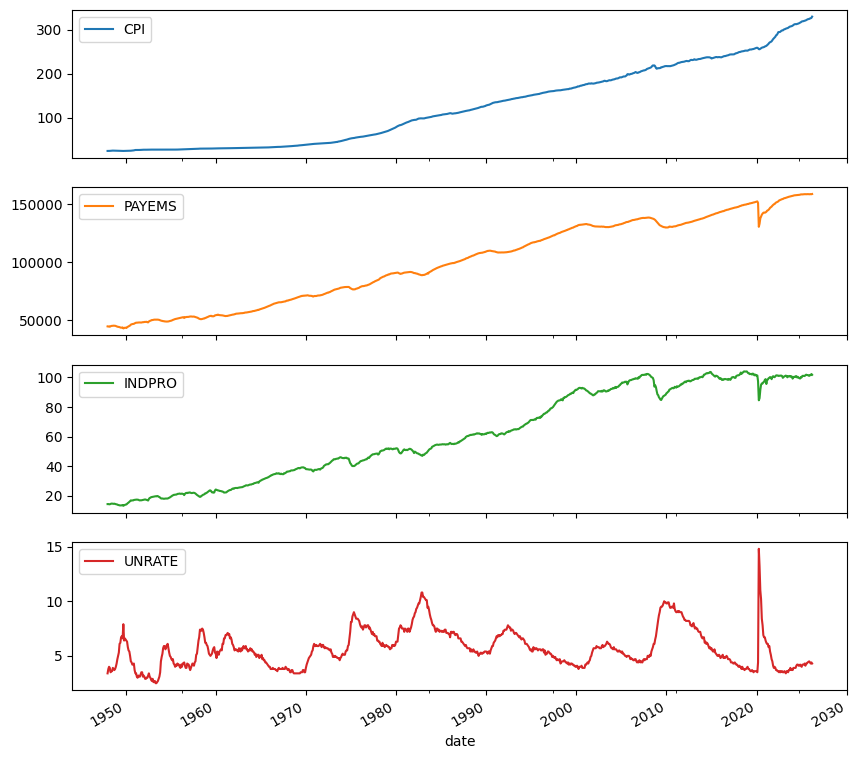

In [19]:
# basic plot to inspect length
df_monthly.plot(x='date', y=['CPI', 'PAYEMS','INDPRO', 'UNRATE'], subplots=True, figsize=(10, 10))

#### Meaning of Variables:

**CPI** -> Consumer Price Index 
<!-- **PCEPI** -> Personal Consumption Expenditures Price Index  -->
**PAYEMS** -> Total Nonfarm Payrolls
<!-- **JTSJOL** -> Job Openings: Total Nonfarm (non-farm workers)
**UMCSENT** -> University of Michigan Sentiment Index -->
**INDPRO** -> Industrial Production Index

**UNRATE** -> Unemployment Rate

### Implementing TFT

**Info on Model**, based on the following paper: [Temporal Fusion Transformers for Interpretable Multi-horizon Time Series Forecasting](https://arxiv.org/abs/1912.09363)


The TFT should handle single or multiple targets and a whole lot of different covariates such as:

- *static covariates*: these are the ones that do not change through the course of the timeseries. In our case we have country, publication source, etc.  
    - could potentially fetch information from [FRED Website on the different variables](https://fred.stlouisfed.org/series/PAYEMS) for more static covariates? 

- *time series covariates*, they actually belong to 2 different groups:

    - known in advance: such as day_of_the_week, month, holidays, etc.

    - unknown in advance: f.i. if we hade the stock level for each product, we would know it just in the past



In [20]:
# adding time varying known covariates
us_holidays = holidays.US()

df_monthly['day_of_week'] = df_monthly['date'].dt.dayofweek
df_monthly['week_of_year'] = df_monthly['date'].dt.isocalendar().week.astype(int)
df_monthly['month'] = df_monthly['date'].dt.month
df_monthly['is_holiday'] = df_monthly['date'].dt.date.apply(lambda d: int(d in us_holidays))

df_monthly['series_id'] = 'macro'

# precompute lags before train/test split
lag_vars = ["CPI", "PAYEMS", "INDPRO", "UNRATE"]
lag_periods = [1, 2, 6, 12]
for col in lag_vars:
    for lag in lag_periods:
        df_monthly[f"{col}_lag_{lag}"] = df_monthly[col].shift(lag)

# drop first 12 rows where lag_12 is undefined
df_monthly = df_monthly.dropna().reset_index(drop=True)

# create time_idx
df_monthly = (df_monthly.merge((df_monthly[['date']].drop_duplicates(ignore_index=True)
.rename_axis('time_idx')).reset_index(), on=['date']))

print(df_monthly.tail(10))
print(f"\nRemaining NAs:\n{df_monthly.isna().sum()[df_monthly.isna().sum() > 0]}")

          date      CPI    PAYEMS    INDPRO  UNRATE  day_of_week  \
916 2025-05-01  320.620  158498.0  100.9655     4.3            3   
917 2025-06-01  321.435  158478.0  101.4785     4.1            6   
918 2025-07-01  322.169  158542.0  101.8940     4.3            1   
919 2025-08-01  323.291  158472.0  101.6247     4.3            4   
920 2025-09-01  324.245  158548.0  101.6680     4.4            0   
921 2025-11-01  325.063  158449.0  101.0810     4.5            5   
922 2025-12-01  326.031  158432.0  101.6113     4.4            0   
923 2026-01-01  326.588  158592.0  101.5954     4.3            3   
924 2026-02-01  327.460  158459.0  102.3440     4.4            6   
925 2026-03-01  330.293  158637.0  101.7898     4.3            6   

     week_of_year  month  is_holiday series_id  ...  PAYEMS_lag_12  \
916            18      5           0     macro  ...       157608.0   
917            22      6           0     macro  ...       157695.0   
918            27      7           0     

In [21]:
# split into test, train
tr_len = round(len(df_monthly) * 0.8)

train = df_monthly.iloc[:tr_len]
test = df_monthly.iloc[tr_len:]
print(train.tail()) # goes until 2004

          date      CPI    PAYEMS   INDPRO  UNRATE  day_of_week  week_of_year  \
736 2010-05-01  217.290  130642.0  91.8230     9.6            5            17   
737 2010-06-01  217.199  130510.0  91.9928     9.4            1            22   
738 2010-07-01  217.605  130415.0  92.3421     9.4            3            26   
739 2010-08-01  217.923  130415.0  92.6805     9.5            6            30   
740 2010-09-01  218.275  130341.0  92.9537     9.5            2            35   

     month  is_holiday series_id  ...  PAYEMS_lag_12  INDPRO_lag_1  \
736      5           0     macro  ...       131466.0       90.5991   
737      6           0     macro  ...       131008.0       91.8230   
738      7           0     macro  ...       130662.0       91.9928   
739      8           0     macro  ...       130472.0       92.3421   
740      9           0     macro  ...       130246.0       92.6805   

     INDPRO_lag_2  INDPRO_lag_6  INDPRO_lag_12  UNRATE_lag_1  UNRATE_lag_2  \
736       90.2

In [22]:
max_encoder_length = 48  # 4 years lookback
max_prediction_length = 12  # 12 months forecast

lag_vars = ["CPI", "PAYEMS", "INDPRO", "UNRATE"]
lag_periods = [1, 2, 6, 12]
lagged_cols = [f"{col}_lag_{lag}" for col in lag_vars for lag in lag_periods]
print(lagged_cols)

training = TimeSeriesDataSet(
    data=train,
    time_idx="time_idx",
    target="INDPRO",
    group_ids=["series_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["series_id"],
    static_reals=[],
    time_varying_known_reals=["time_idx", "day_of_week", "week_of_year", "month", "is_holiday"],
    time_varying_known_categoricals=[],
    time_varying_unknown_reals=["CPI", "PAYEMS", "INDPRO"] + lagged_cols,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, train, predict=True, stop_randomization=True)

batch_size = 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

['CPI_lag_1', 'CPI_lag_2', 'CPI_lag_6', 'CPI_lag_12', 'PAYEMS_lag_1', 'PAYEMS_lag_2', 'PAYEMS_lag_6', 'PAYEMS_lag_12', 'INDPRO_lag_1', 'INDPRO_lag_2', 'INDPRO_lag_6', 'INDPRO_lag_12', 'UNRATE_lag_1', 'UNRATE_lag_2', 'UNRATE_lag_6', 'UNRATE_lag_12']


### Training and Evaluating TFT

In [25]:
PATIENCE = 30
MAX_EPOCHS = 120
LEARNING_RATE = 0.03
OPTUNA = False # hyperparam opt

In [ ]:
from lightning.pytorch.callbacks.progress import TQDMProgressBar

early_stop_callback = EarlyStopping(monitor="train_loss", min_delta=1e-2, patience=PATIENCE, verbose=False, mode="min")
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",  # uses MPS on Apple Silicon, CPU otherwise
    devices=1,
    enable_model_summary=True,
    gradient_clip_val=0.25,
    limit_train_batches=10,
    callbacks=[lr_logger, early_stop_callback, TQDMProgressBar(refresh_rate=1)],
    logger=logger,
    suggest_integrations=False, # default True
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=LEARNING_RATE,
    lstm_layers=2,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.2,
    hidden_continuous_size=8,
    output_size=1,  # 7 quantiles by default
    loss=SMAPE(),
    log_interval=10,
    reduce_on_plateau_patience=4
)

tft.to(DEVICE)
print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 41.6k


In [27]:
# add tqdm for progress report
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ SMAPE                           │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    448 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 17.9 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     17 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 41.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 41.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 666                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 53: 100%|██████████| 5/5 [00:03<00:00,  1.32it/s, v_num=6, train_loss_step=0.0179, val_loss=0.0548, train_loss_epoch=0.0185]


In [28]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
predictions = best_tft.predict(val_dataloader, mode="prediction")
# print(predictions[:10])
# print(predictions.shape)

raw_output = best_tft.predict(val_dataloader, mode="raw", return_x=True)
# this is how to unpack it 
raw_predictions = raw_output.output
x = raw_output.x

sm = SMAPE()
print(f"Validation median SMAPE loss: {sm.loss(actuals, predictions).mean(axis=1).median().item()}")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with th

Validation median SMAPE loss: 0.05484426021575928


### Fit Naive and TFT model for all variables of interest
for reference these variables are: "CPI", "PAYEMS", "INDPRO", "UNRATE"

In [45]:
results = {}  # stores {target: {'model': ..., 'predictions': ..., 'actuals': ...}}
naive_results = {}
tft_loss = {}

# use all variables of interest as target once
for target in lag_vars:
    print(f'=== Training TFT for target: {target} ===')

    ds = TimeSeriesDataSet(
        data=train,
        time_idx='time_idx',
        target=target,
        group_ids=['series_id'],
        max_encoder_length=max_encoder_length,
        max_prediction_length=max_prediction_length,
        static_categoricals=['series_id'],
        static_reals=[],
        time_varying_known_reals=['time_idx', 'day_of_week', 'week_of_year', 'month', 'is_holiday'],
        time_varying_known_categoricals=[],
        time_varying_unknown_reals=[v for v in lag_vars if v != target] + [target] + lagged_cols,
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        allow_missing_timesteps=True,
    )
    val_ds = TimeSeriesDataSet.from_dataset(ds, train, predict=True, stop_randomization=True)
    train_dl = ds.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
    val_dl = val_ds.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)
    naive_results[target] = val_dl

    model = TemporalFusionTransformer.from_dataset(
        ds,
        learning_rate=LEARNING_RATE,
        lstm_layers=2,
        hidden_size=16,
        attention_head_size=2,
        dropout=0.2,
        hidden_continuous_size=8,
        output_size=1,
        loss=SMAPE(),
        log_interval=10,
        reduce_on_plateau_patience=4,
    )

    t = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="auto",
        devices=1,
        gradient_clip_val=0.25,
        limit_train_batches=10,
        callbacks=[
            EarlyStopping(monitor="train_loss", min_delta=1e-2, patience=PATIENCE, verbose=False, mode="min"),
            TQDMProgressBar(refresh_rate=2),
        ],
        enable_model_summary=False,
        logger=False,
    )
    t.fit(model, train_dataloaders=train_dl, val_dataloaders=val_dl)

    best = TemporalFusionTransformer.load_from_checkpoint(t.checkpoint_callback.best_model_path)
    preds = best.predict(val_dl, mode="prediction")
    acts = torch.cat([y[0] for x, y in iter(val_dl)])

    results[target] = {'model': best, 'predictions': preds, 'actuals': acts, 'val_dl': val_dl}
    tft_loss[target] = SMAPE().loss(acts, preds).mean(axis=1).median().item()
    print(f"  Median SMAPE: {SMAPE().loss(acts, preds).mean(axis=1).median().item():.4f}")

print("Done. Models stored in results[target].")

=== Training TFT for target: CPI ===


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Epoch 52: 100%|██████████| 5/5 [00:02<00:00,  1.82it/s, train_loss_step=0.00616, val_loss=0.00178, train_loss_epoch=0.00601]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with th

  Median SMAPE: 0.0018
=== Training TFT for target: PAYEMS ===
Epoch 55: 100%|██████████| 5/5 [00:02<00:00,  1.81it/s, train_loss_step=0.00812, val_loss=0.044, train_loss_epoch=0.00769] 


...

  Median SMAPE: 0.0440
=== Training TFT for target: INDPRO ===
Epoch 79: 100%|██████████| 5/5 [00:03<00:00,  1.66it/s, train_loss_step=0.020, val_loss=0.0606, train_loss_epoch=0.0218] 


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with th

  Median SMAPE: 0.0606
=== Training TFT for target: UNRATE ===
Epoch 75: 100%|██████████| 5/5 [00:02<00:00,  1.79it/s, train_loss_step=0.0881, val_loss=0.134, train_loss_epoch=0.0887]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  Median SMAPE: 0.1335
Done. Models stored in results[target].


In [46]:
# losses = pd.DataFrame(columns= ["naive", "tft"])
naive_loss = {}


for target in naive_results.keys():
    print(f'=== Training Naive Model for: {target} ===')
    # naive model 
    # TODO: on all 3 variables
    actuals = torch.cat([y for x, (y, weight) in iter(naive_results[target])])
    baseline_predictions = Baseline().predict(naive_results[target])
    (actuals - baseline_predictions).abs().mean().item()

    naive_loss[target] = sm.loss(actuals, baseline_predictions).mean(axis = 1).median().item()

    print(f"Median loss for naive prediction on validation: {sm.loss(actuals, baseline_predictions).mean(axis = 1).median().item()}")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


=== Training Naive Model for: CPI ===


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with th

Median loss for naive prediction on validation: 0.007143558468669653
=== Training Naive Model for: PAYEMS ===
Median loss for naive prediction on validation: 0.002173694549128413
=== Training Naive Model for: INDPRO ===
Median loss for naive prediction on validation: 0.03434445336461067
=== Training Naive Model for: UNRATE ===
Median loss for naive prediction on validation: 0.018911590799689293


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


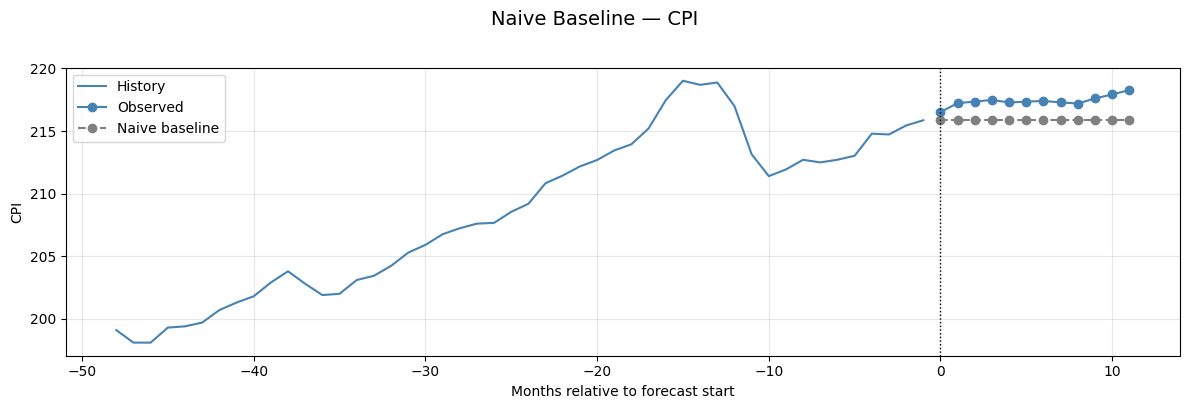

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


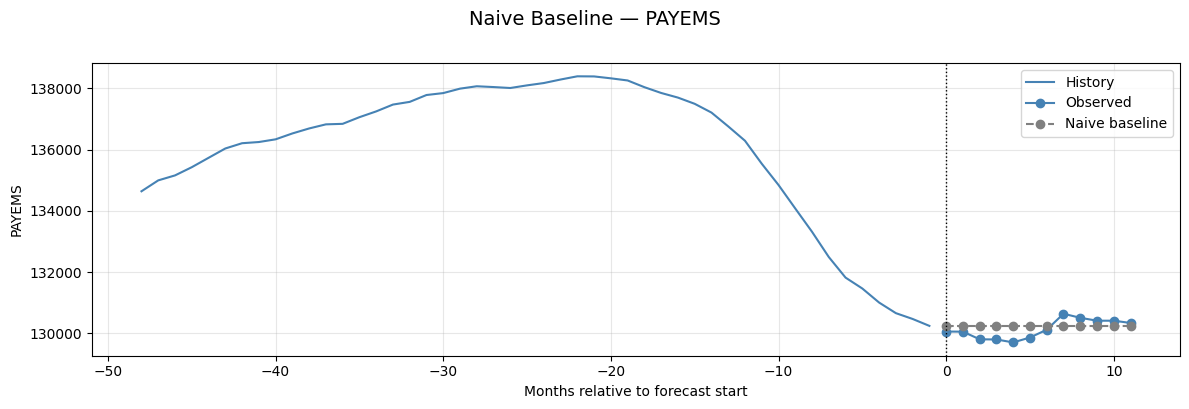

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


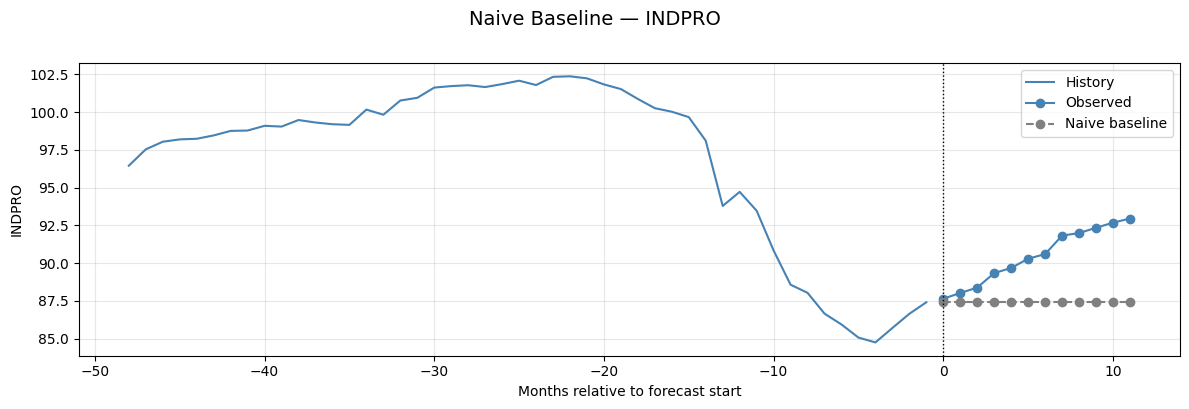

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


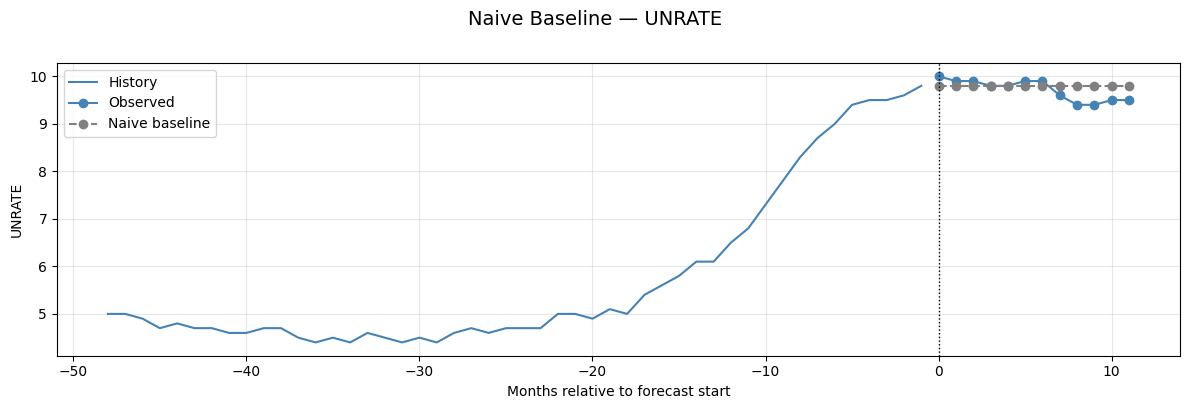

In [47]:
# plot naive baseline for every variable of interest
n_plots = 4

for target in lag_vars:
    val_dl = results[target]['val_dl']
    acts = results[target]['actuals']
    baseline_preds = Baseline().predict(val_dl)

    # encoder history from the first (large) validation batch
    x_b, _ = next(iter(val_dl))

    n = min(n_plots, len(acts))
    fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]

    for idx in range(n):
        ax = axes[idx]
        history = x_b["encoder_target"][idx].numpy()
        obs = acts[idx].numpy()
        pred = baseline_preds[idx].numpy()

        n_hist = len(history)
        hist_steps = range(-n_hist, 0)
        future_steps = range(0, len(obs))

        ax.plot(hist_steps, history, color="steelblue", label="History")
        ax.plot(future_steps, obs, marker="o", color="steelblue", label="Observed")
        ax.plot(future_steps, pred, marker="o", linestyle="--", color="gray", label="Naive baseline")
        ax.axvline(0, color="black", linestyle=":", linewidth=1)
        ax.set_xlabel("Months relative to forecast start")
        ax.set_ylabel(target)
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"Naive Baseline — {target}", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


=== Predictions for target: CPI ===


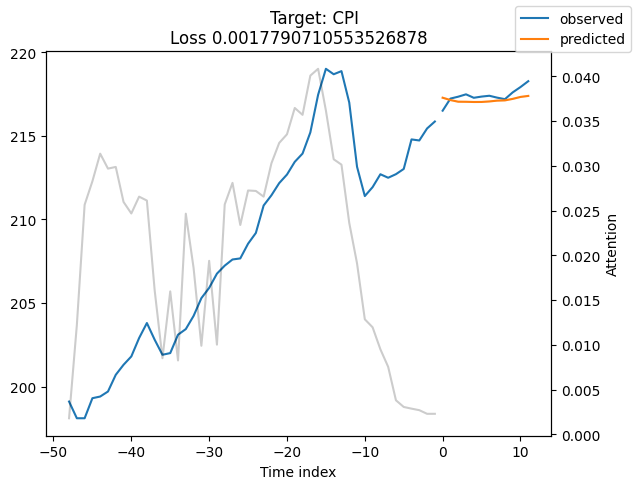

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


=== Predictions for target: PAYEMS ===


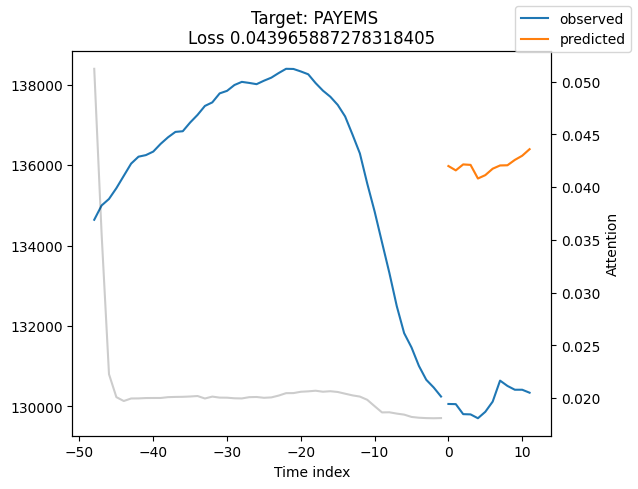

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


=== Predictions for target: INDPRO ===


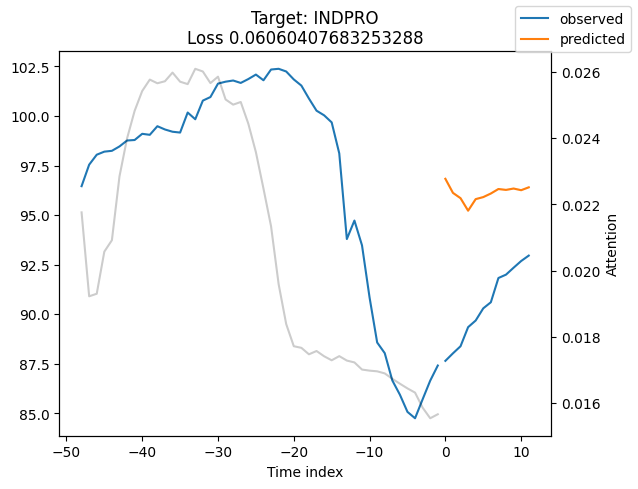

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


=== Predictions for target: UNRATE ===


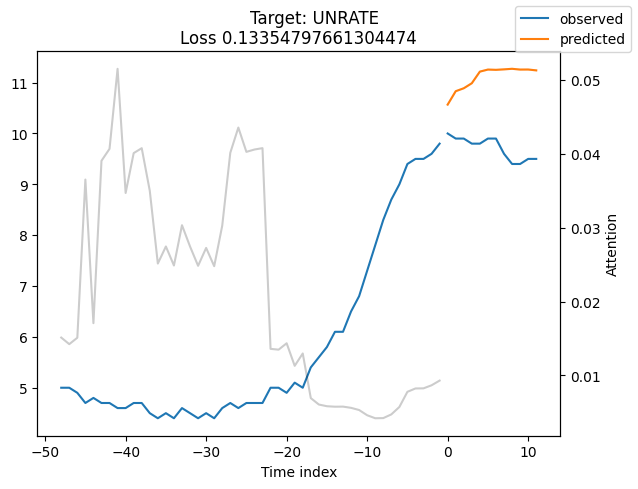

In [48]:
for target, res in results.items():
    print(f'=== Predictions for target: {target} ===')
    raw_out = res['model'].predict(res['val_dl'], mode='raw', return_x=True)
    raw_preds = raw_out.output
    x_in = raw_out.x
    for idx in range(raw_preds.prediction.shape[0]):
        res['model'].plot_prediction(x_in, raw_preds, idx=idx, add_loss_to_title=True)
        plt.suptitle(f'Target: {target}', y=1.01)
        plt.show()

**Interpretation**: These plots dont look super intuitive, because the method `plot_predictions` labels show attention, but on the left side you see the actual value, in our case, CPI, PAYEMS, INDPRO, UNRATE. 

To compare the results for the Naive Baseline and the TFT, i will plot the results:

In [55]:
losses = pd.DataFrame({
    "Naive": [naive_loss[target] for target in lag_vars],
    "TFT": [tft_loss[target] for target in lag_vars],
}, index=lag_vars)
print(losses)

           Naive       TFT
CPI     0.007144  0.001779
PAYEMS  0.002174  0.043966
INDPRO  0.034344  0.060604
UNRATE  0.018912  0.133548


So, the naive is better for all except for CPI for now, let's see how this changes with more metadata